# Carbon utilization (Biolog) analysis

Replicates GEMcompare's `Pipeline/2_Comparison/2.5_CarbonUtilization.py` Biolog test for the 7
models used from here onward (`iBsu1103`, `iBsu1103v2`, `iBsu1209` excluded - see
`PROJECT_CONTEXT.md`). Experimental data: `data/datasets/CarbonUtilization.csv`.
Exchange ids are looked up directly against each model - `001_standardization.ipynb`'s
carbon-utilization id-correction step already renamed every resolvable reaction to match the
dataset's ids, so no separate id-mapping step is needed here.

**Method**: for each model, close every carbon-containing exchange, then open one experimental
carbon source at a time (`-7.5` mmol/gDW/h, GEMcompare's default) and check if growth clears
`1e-3`. Compared against the Biolog `+`/`-` call; ambiguous `x` calls are excluded, blank/NaN
counts as `-`.

Outputs: `../results/tables/carbon_utilization_Summary.csv`,
`../results/tables/carbon_utilization_Per_Substrate_Outcomes.csv`, and two figures
(`Plot_CarbonUtilization_metrics_comparison.pdf`, `Carbon_Utilization_Heatmap.pdf`). Models
appear in both figures in the manuscript's canonical order.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cobra.io import read_sbml_model
from matplotlib.patches import Patch

# Typography matched to every other figure in the paper.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    # Arial for math too; matplotlib defaults to DejaVu inside $...$.
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "pdf.fonttype": 42,   # keep text as text in the PDF, not outlines
})

MODEL_DIR = os.path.join("..", "data", "models", "02_final_annotated")
# Canonical model order used throughout the manuscript. Both figures below take their model
# order from here (via `model_names`), so this is the single place that sets it.
MODELS = ["iYO844", "iBsu1147", "eciYO844", "iBB1018", "iBsu1147R", "ecBSU1", "Submodel"]
UPTAKE_RATE = 7.5        # mmol/gDW/h, matches GEMcompare config.yaml comparison.biolog.uptake
GROWTH_THRESHOLD = 1e-3  # matches GEMcompare config.yaml comparison.biolog.threshold

models = {name: read_sbml_model(os.path.join(MODEL_DIR, f"{name}.xml")) for name in MODELS}
print(f"[INFO] Loaded {len(models)} models")

Set parameter Username


Set parameter LicenseID to value 2695449


--------------------------------------------


--------------------------------------------


Academic license - for non-commercial use only - expires 2026-08-13


'' is not a valid SBML 'SId'.


'' is not a valid SBML 'SId'.


'' is not a valid SBML 'SId'.


[INFO] Loaded 7 models


In [2]:
def parse_experimental_result(value):
    """True/False/None (ambiguous), matching GEMcompare's parse_experimental_result."""
    if pd.isna(value):
        return False
    value_str = str(value).strip()
    if value_str == "+":
        return True
    elif value_str == "-":
        return False
    elif value_str == "x":
        return None
    return False


carbon_sources = pd.read_csv("../data/datasets/CarbonUtilization.csv")
raw_rows = [(row["ID"], row["result"]) for _, row in carbon_sources.iterrows()
            if not pd.isna(row["ID"])]

experimental = {}   # entry (raw ID string, possibly comma-separated candidates) -> bool
ambiguous = []
for entry, result in raw_rows:
    parsed = parse_experimental_result(result)
    if parsed is None:
        ambiguous.append(entry)
    else:
        experimental[entry] = parsed

print(f"[INFO] {len(experimental)} carbon sources with a usable experimental result "
      f"({sum(experimental.values())} positive, {len(experimental) - sum(experimental.values())} negative), "
      f"{len(ambiguous)} ambiguous ('x') excluded")


def resolve_exchange_id(entry, model):
    """Entries are already the model's reaction id after standardization, except a couple that
    list synonym candidates (comma-separated) - try each in order, first match wins."""
    for candidate in str(entry).split(","):
        candidate = candidate.strip()
        if candidate in model.reactions:
            return candidate
    return None

[INFO] 96 carbon sources with a usable experimental result (73 positive, 23 negative), 15 ambiguous ('x') excluded


## Run the Biolog-style FBA test per model

In [3]:
def calculate_metrics(tp, fp, tn, fn):
    metrics = {}
    metrics["tpr"] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    metrics["tnr"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    metrics["fdr"] = fp / (fp + tp) if (fp + tp) > 0 else 0.0
    metrics["precision"] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    metrics["recall"] = metrics["tpr"]
    metrics["specificity"] = metrics["tnr"]
    denom = metrics["precision"] + metrics["recall"]
    metrics["f1_score"] = 2 * metrics["precision"] * metrics["recall"] / denom if denom > 0 else 0.0
    total = tp + fp + tn + fn
    metrics["accuracy"] = (tp + tn) / total if total > 0 else 0.0
    mcc_denom = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    metrics["mcc"] = (tp * tn - fp * fn) / mcc_denom if mcc_denom > 0 else 0.0
    return metrics


summary_rows = []
# outcome per (substrate, model): "TP"/"TN"/"FP"/"FN"/"untested" - feeds the heatmap below
outcome_records = []

for name, model in models.items():
    carbon_exchange_ids = [r.id for r in model.exchanges
                           if any((met.elements or {}).get("C", 0) > 0 for met in r.metabolites)]
    for rid in carbon_exchange_ids:
        model.reactions.get_by_id(rid).lower_bound = 0.0

    tp = fp = tn = fn = tested = 0
    for entry, exp_growth in experimental.items():
        resolved_id = resolve_exchange_id(entry, model)
        if resolved_id is None:
            outcome_records.append({"substrate": entry, "model": name, "outcome": "untested"})
            continue
        rxn = model.reactions.get_by_id(resolved_id)
        rxn.lower_bound = -UPTAKE_RATE
        solution = model.optimize()
        pred_growth = solution.status == "optimal" and solution.objective_value >= GROWTH_THRESHOLD
        rxn.lower_bound = 0.0
        tested += 1
        if exp_growth and pred_growth:
            tp += 1
            outcome = "TP"
        elif not exp_growth and pred_growth:
            fp += 1
            outcome = "FP"
        elif not exp_growth and not pred_growth:
            tn += 1
            outcome = "TN"
        else:
            fn += 1
            outcome = "FN"
        outcome_records.append({"substrate": entry, "model": name, "outcome": outcome})

    metrics = calculate_metrics(tp, fp, tn, fn)
    summary_rows.append({
        "model": name,
        "sources_tested": tested, "sources_in_dataset": len(experimental),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "TPR": round(metrics["tpr"], 4), "TNR": round(metrics["tnr"], 4),
        "FDR": round(metrics["fdr"], 4), "Precision": round(metrics["precision"], 4),
        "Recall": round(metrics["recall"], 4), "Specificity": round(metrics["specificity"], 4),
        "F1_Score": round(metrics["f1_score"], 4), "Accuracy": round(metrics["accuracy"], 4),
        "MCC": round(metrics["mcc"], 4),
    })
    print(f"[OK] {name}: tested {tested}/{len(experimental)}, "
          f"TP={tp} FP={fp} TN={tn} FN={fn}, accuracy={metrics['accuracy']:.3f}")

results_df = pd.DataFrame(summary_rows)
outcome_df = pd.DataFrame(outcome_records)
results_df

C:\Users\felip\anaconda4\envs\tesis_fba\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


[OK] iYO844: tested 78/96, TP=63 FP=3 TN=6 FN=6, accuracy=0.885


C:\Users\felip\anaconda4\envs\tesis_fba\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


[OK] iBsu1147: tested 76/96, TP=58 FP=6 TN=4 FN=8, accuracy=0.816


...

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


[OK] ecBSU1: tested 76/96, TP=47 FP=2 TN=8 FN=19, accuracy=0.724


C:\Users\felip\anaconda4\envs\tesis_fba\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


[OK] Submodel: tested 71/96, TP=54 FP=2 TN=8 FN=7, accuracy=0.873


,model,sources_tested,sources_in_dataset,TP,FP,TN,FN,TPR,TNR,FDR,Precision,Recall,Specificity,F1_Score,Accuracy,MCC
0,iYO844,78,96,63,3,6,6,0.9130,0.6667,0.0455,0.9545,0.9130,0.6667,0.9333,0.8846,0.5133
1,iBsu1147,76,96,58,6,4,8,0.8788,0.4000,0.0938,0.9062,0.8788,0.4000,0.8923,0.8158,0.2584
2,eciYO844,77,96,38,0,9,30,0.5588,1.0000,0.0000,1.0000,0.5588,1.0000,0.7170,0.6104,0.3591
3,iBB1018,78,96,63,3,6,6,0.9130,0.6667,0.0455,0.9545,0.9130,0.6667,0.9333,0.8846,0.5133
4,iBsu1147R,76,96,47,2,8,19,0.7121,0.8000,0.0408,0.9592,0.7121,0.8000,0.8174,0.7237,0.3617
5,ecBSU1,76,96,47,2,8,19,0.7121,0.8000,0.0408,0.9592,0.7121,0.8000,0.8174,0.7237,0.3617
6,Submodel,71,96,54,2,8,7,0.8852,0.8000,0.0357,0.9643,0.8852,0.8000,0.9231,0.8732,0.5839


## Save result table

In [4]:
tables_dir = os.path.join("..", "results", "tables")
os.makedirs(tables_dir, exist_ok=True)

summary_path = os.path.join(tables_dir, "carbon_utilization_Summary.csv")
outcomes_path = os.path.join(tables_dir, "carbon_utilization_Per_Substrate_Outcomes.csv")
results_df.to_csv(summary_path, index=False)
outcome_df.to_csv(outcomes_path, index=False)

print(f"[INFO] Results written to {summary_path} and {outcomes_path}")

[INFO] Results written to ..\results\tables\carbon_utilization_Summary.csv and ..\results\tables\carbon_utilization_Per_Substrate_Outcomes.csv


## MCC comparison plot (main text)

Matthews correlation coefficient per model, in the manuscript's canonical model order. MCC is the
single figure that accounts for all four cells of the confusion matrix, which matters here because
the Biolog dataset is heavily imbalanced (73 positive vs. 23 negative calls) — accuracy on its own
flatters a model that simply predicts growth everywhere. The full metric set (accuracy, TPR, TNR,
FDR, precision, recall, specificity, F1) is in `carbon_utilization_Summary.csv`.

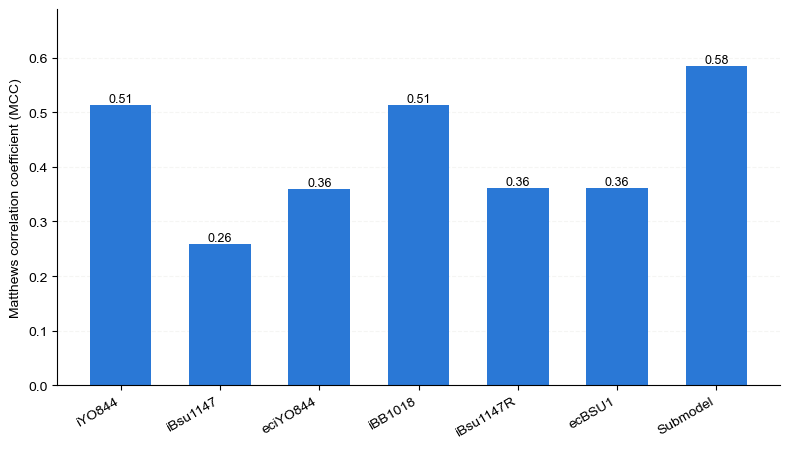

[INFO] MCC plot saved to ..\results\figures\Plot_CarbonUtilization_metrics_comparison.pdf


In [5]:
figures_dir = os.path.join("..", "results", "figures")
os.makedirs(figures_dir, exist_ok=True)

# Single series: no legend needed, one colour carries the chart.
BAR_COLOR = "#2a78d6"

model_names = results_df["model"].tolist()
values = results_df["MCC"].tolist()
x = np.arange(len(model_names))

fig, ax = plt.subplots(figsize=(8, 4.6))
bars = ax.bar(x, values, 0.62, color=BAR_COLOR, linewidth=0)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{v:.2f}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Matthews correlation coefficient (MCC)")
# Top follows the data; a fixed 1.0 squashed the MCC range into the bottom half.
ax.set_ylim(0, max(values) * 1.18)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha="right")
ax.grid(axis="y", alpha=0.3, linestyle="--", color="#e1e0d9")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
metrics_plot_path = os.path.join(figures_dir, "Plot_CarbonUtilization_metrics_comparison.pdf")
plt.savefig(metrics_plot_path, bbox_inches="tight")
plt.show()
print(f"[INFO] MCC plot saved to {metrics_plot_path}")

## Per-substrate outcome heatmap (supplementary material)

For every substrate x model pair: green = correct, red = false negative (missed growth), orange
= false positive (spurious growth), gray = untested (reaction absent/unresolved). This is the
substrate-level detail the summary metrics collapse away - e.g. it shows `eciYO844`'s false
negatives clustering on TCA-cycle intermediates rather than being scattered.

[INFO] 13 substrates untested in every model, excluded from the figure:
EX_13ppd_e,EX_12ppd__R_e EX_3ohglutac_e EX_abt__D_e EX_caproic_e EX_cspg_c_e EX_fuc_e EX_galctn__D_e EX_sebacid_e EX_tartr__D_e EX_tcb_e EX_thr__D_e EX_tym_e EX_xylt_e


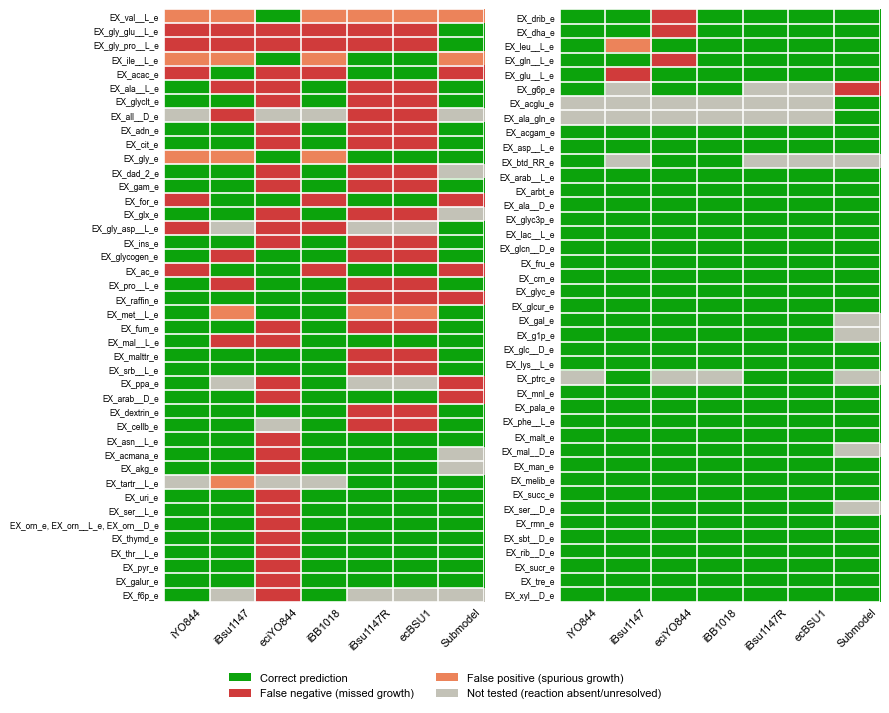

[INFO] Heatmap saved to ..\results\figures\Carbon_Utilization_Heatmap.pdf


In [6]:
# Status palette, kept separate from the categorical model colours.
OUTCOME_CODES = {"TP": 0, "TN": 0, "FN": 1, "FP": 2, "untested": 3}
OUTCOME_LEGEND = [
    ("Correct prediction", "#0ca30c"),
    ("False negative (missed growth)", "#d03b3b"),
    ("False positive (spurious growth)", "#ec835a"),
    ("Not tested (reaction absent/unresolved)", "#c3c2b7"),
]

pivot = outcome_df.pivot(index="substrate", columns="model", values="outcome")
pivot = pivot[model_names]

# Substrates absent from every model are a scope gap, not an outcome: dropped here, listed below.
all_untested = pivot[(pivot == "untested").all(axis=1)].index.tolist()
pivot = pivot.drop(index=all_untested)
print(f"[INFO] {len(all_untested)} substrates untested in every model, excluded from the figure:")
print(" ".join(all_untested))

# Order substrates so FNs/FPs cluster together rather than sitting in dataset order.
error_count = (pivot.isin(["FN", "FP"])).sum(axis=1)
pivot = pivot.loc[error_count.sort_values(ascending=False).index]

from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(["#0ca30c", "#d03b3b", "#ec835a", "#c3c2b7"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

# Two side-by-side panels (rather than one very tall column) so the figure fits a single page.
half = -(-len(pivot) // 2)  # ceil division
panels = [pivot.iloc[:half], pivot.iloc[half:]]

fig, axes = plt.subplots(1, 2, figsize=(9, max(6, 0.16 * half)))
for ax, panel in zip(axes, panels):
    code_matrix = panel.map(lambda v: OUTCOME_CODES.get(v, 3))
    ax.imshow(code_matrix.values, cmap=cmap, norm=norm, aspect="auto")
    ax.set_xticks(range(len(model_names)))
    # ha="center" so each label sits under the middle of its column; with the default
    # ha="right" the 45-degree text anchors by its end and drifts left of the column.
    ax.set_xticklabels(model_names, rotation=45, ha="center", fontsize=8)
    ax.set_yticks(range(len(panel)))
    ax.set_yticklabels(panel.index, fontsize=6)
    ax.set_xticks(np.arange(-0.5, len(model_names), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(panel), 1), minor=True)
    ax.grid(which="minor", color="#fcfcfb", linewidth=1.2)
    ax.tick_params(which="minor", length=0)
    ax.tick_params(which="major", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()

legend_handles = [Patch(facecolor=color, edgecolor="none", label=label) for label, color in OUTCOME_LEGEND]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.005),
           ncol=2, frameon=False, fontsize=8)

heatmap_path = os.path.join(figures_dir, "Carbon_Utilization_Heatmap.pdf")
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"[INFO] Heatmap saved to {heatmap_path}")